# Speech Emotion Recognition - Exploratory Data Analysis

**RAVDESS Dataset Deep Dive**

This notebook provides comprehensive EDA for the RAVDESS Emotional Speech Audio dataset, expanding on the analysis in the main project notebook with:

1. **Dataset Overview & Validation**
2. **Class Distribution Analysis**
3. **Audio Properties Analysis** (duration, sampling rate, amplitude)
4. **Waveform & Spectrogram Visualization**
5. **Feature Extraction & Analysis** (MFCCs, Chroma, Spectral features)
6. **Feature Distributions by Emotion**
7. **Dimensionality Reduction** (PCA, t-SNE)
8. **Correlation Analysis**
9. **Actor & Gender Analysis**
10. **Intensity Analysis**

## Audio Feature Glossary (Plain English)

Before diving into the analysis, here's what each audio feature means in simple terms:

### Basic Audio Properties
| Feature | What It Measures | Real-World Analogy |
|---------|-----------------|--------------------|
| **Duration** | Length of the audio clip in seconds | How long someone talks |
| **Sample Rate** | How many audio snapshots per second (Hz) | Higher = more detail, like camera resolution |
| **Amplitude** | The height of sound waves | How loud the sound is at any moment |

### Energy & Loudness Features
| Feature | What It Measures | Real-World Analogy |
|---------|-----------------|--------------------|
| **RMS Energy** | Average loudness/volume over time | Speaking volume - whisper vs shout |
| **Max Amplitude** | The loudest moment in the clip | The peak of a yell or emphasis |

### Pitch & Tone Features  
| Feature | What It Measures | Real-World Analogy |
|---------|-----------------|--------------------|
| **Pitch (F0)** | How high or low the voice sounds | Bass voice vs soprano voice |
| **Pitch Mean** | Average pitch throughout the clip | Overall voice height |
| **Pitch Std** | How much pitch varies | Monotone (low) vs expressive/sing-song (high) |
| **Tempo** | Speed/rhythm of speech | Fast talking vs slow, deliberate speech |

### Spectral Features (Frequency Analysis)
| Feature | What It Measures | Real-World Analogy |
|---------|-----------------|--------------------|
| **Spectral Centroid** | The 'center of mass' of frequencies | Brightness of sound - bright/sharp vs dull/muffled |
| **Spectral Bandwidth** | Range of frequencies present | Narrow (pure tone) vs wide (rich/complex sound) |
| **Spectral Rolloff** | Frequency below which 85% of energy exists | Where most of the sound energy lives |
| **Spectral Contrast** | Difference between peaks and valleys in spectrum | How 'textured' or varied the sound is |
| **Zero Crossing Rate (ZCR)** | How often the audio wave crosses zero | High for noisy/breathy sounds, low for smooth tones |

### Advanced Features
| Feature | What It Measures | Real-World Analogy |
|---------|-----------------|--------------------|
| **MFCCs** | Mel-Frequency Cepstral Coefficients - compact representation of the sound's 'shape' | Like a fingerprint of someone's voice quality |
| **MFCC_0** | Overall energy/loudness | Volume level |
| **MFCC_1-12** | Different aspects of voice timbre/texture | What makes your voice sound like YOU |
| **MFCC Delta** | How MFCCs change over time | Speech dynamics - is the voice changing? |
| **MFCC Delta-Delta** | Acceleration of MFCC changes | How quickly speech patterns shift |
| **Chroma** | Which musical notes are present (C, C#, D, etc.) | The 'musicality' or tonal content of speech |
| **Mel Spectrogram** | Visual heatmap of frequency content over time | A picture of what frequencies are active when |

### Why These Features Matter for Emotion Recognition

| Emotion | Key Audio Characteristics |
|---------|---------------------------|
| **Angry** | High energy (RMS), high pitch, fast tempo, high spectral centroid (sharp/bright) |
| **Sad** | Low energy, low pitch, slow tempo, narrow bandwidth (monotone) |
| **Happy** | Moderate-high energy, variable pitch (expressive), fast tempo |
| **Fearful** | Variable energy, high pitch, high zero-crossing rate (breathy/tense) |
| **Neutral** | Moderate everything, low variation in all features |
| **Calm** | Low energy, steady pitch, slow tempo |
| **Surprised** | Sudden high pitch, high energy bursts |
| **Disgust** | Low pitch, irregular tempo, nasal quality |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import glob
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully")
print(f"Librosa version: {librosa.__version__}")

Libraries loaded successfully
Librosa version: 0.11.0


## 1. Load and Parse Dataset

In [13]:
# Configure data path - works locally
DATA_DIR = Path("data")

# RAVDESS filename structure:
# Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav
# Example: 03-01-05-01-02-01-12.wav

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

INTENSITY_MAP = {
    "01": "normal",
    "02": "strong",
}

STATEMENT_MAP = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door",
}

def parse_ravdess_filename(filepath):
    """Extract all metadata from RAVDESS filename."""
    name = Path(filepath).stem
    parts = name.split("-")
    if len(parts) != 7:
        return None
    
    actor_id = int(parts[6])
    return {
        "modality": parts[0],
        "vocal_channel": parts[1],
        "emotion_code": parts[2],
        "emotion_label": EMOTION_MAP.get(parts[2]),
        "intensity_code": parts[3],
        "intensity_label": INTENSITY_MAP.get(parts[3]),
        "statement_code": parts[4],
        "statement_text": STATEMENT_MAP.get(parts[4]),
        "repetition": parts[5],
        "actor_id": parts[6],
        "gender": "male" if actor_id % 2 == 1 else "female",
    }

# Find all wav files
wav_paths = sorted(glob.glob(str(DATA_DIR / "Actor_*" / "*.wav")))
print(f"Found {len(wav_paths)} .wav files")

# Build dataframe
rows = []
for p in wav_paths:
    parsed = parse_ravdess_filename(p)
    if parsed:
        rows.append({"file_path": p, **parsed})

df = pd.DataFrame(rows)
print(f"\nDataframe shape: {df.shape}")
df.head()

Found 1440 .wav files

Dataframe shape: (1440, 12)


,file_path,modality,vocal_channel,emotion_code,emotion_label,intensity_code,intensity_label,statement_code,statement_text,repetition,actor_id,gender
0,data\Actor_01\03-01-01-01-01-01-01.wav,03,01,01,neutral,01,normal,01,Kids are talking by the door,01,01,male
1,data\Actor_01\03-01-01-01-01-02-01.wav,03,01,01,neutral,01,normal,01,Kids are talking by the door,02,01,male
2,data\Actor_01\03-01-01-01-02-01-01.wav,03,01,01,neutral,01,normal,02,Dogs are sitting by the door,01,01,male
3,data\Actor_01\03-01-01-01-02-02-01.wav,03,01,01,neutral,01,normal,02,Dogs are sitting by the door,02,01,male
4,data\Actor_01\03-01-02-01-01-01-01.wav,03,01,02,calm,01,normal,01,Kids are talking by the door,01,01,male


## 2. Dataset Overview

In [14]:
print("=" * 50)
print("RAVDESS DATASET SUMMARY")
print("=" * 50)
print(f"Total audio files: {len(df)}")
print(f"Unique emotions: {df['emotion_label'].nunique()}")
print(f"Unique actors: {df['actor_id'].nunique()}")
print(f"\nEmotions: {sorted(df['emotion_label'].unique())}")
print(f"\nIntensity levels: {df['intensity_label'].unique().tolist()}")
print(f"\nGender distribution:")
print(df['gender'].value_counts())
print(f"\nStatements:")
for code, text in STATEMENT_MAP.items():
    print(f"  {code}: \"{text}\"")

RAVDESS DATASET SUMMARY
Total audio files: 1440
Unique emotions: 8
Unique actors: 24

Emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Intensity levels: ['normal', 'strong']

Gender distribution:
gender
male      720
female    720
Name: count, dtype: int64

Statements:
  01: "Kids are talking by the door"
  02: "Dogs are sitting by the door"


## 3. Class Distribution Analysis

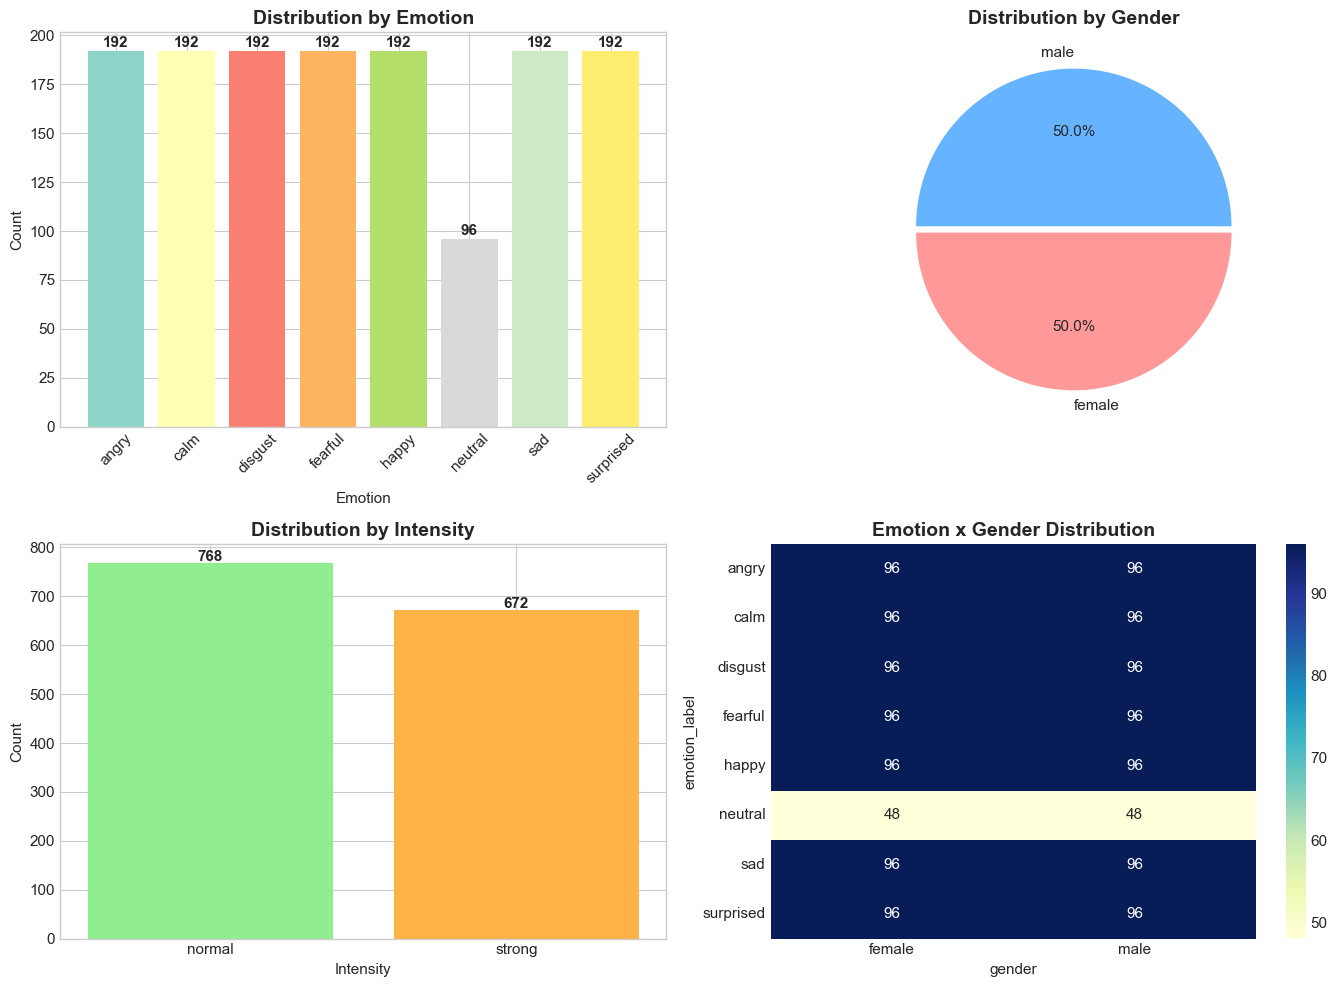


Note: 'neutral' has half the samples (96 vs 192) because neutral emotion
only has 'normal' intensity, not 'strong' intensity.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Emotion distribution
emotion_counts = df['emotion_label'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
axes[0, 0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0, 0].set_title('Distribution by Emotion', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Emotion')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(emotion_counts.values):
    axes[0, 0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[0, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
               colors=['#66b3ff', '#ff9999'], explode=(0.02, 0.02))
axes[0, 1].set_title('Distribution by Gender', fontsize=14, fontweight='bold')

# Intensity distribution
intensity_counts = df['intensity_label'].value_counts()
axes[1, 0].bar(intensity_counts.index, intensity_counts.values, color=['#90EE90', '#FFB347'])
axes[1, 0].set_title('Distribution by Intensity', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate(intensity_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Emotion x Gender heatmap
emotion_gender = pd.crosstab(df['emotion_label'], df['gender'])
sns.heatmap(emotion_gender, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Emotion x Gender Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: 'neutral' has half the samples (96 vs 192) because neutral emotion")
print("only has 'normal' intensity, not 'strong' intensity.")

## 4. Audio Properties Analysis

In [16]:
# Extract audio properties for all files
print("Extracting audio properties...")
audio_props = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Analyzing audio files"):
    try:
        y, sr = librosa.load(row['file_path'], sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        rms = np.sqrt(np.mean(y**2))
        max_amp = np.max(np.abs(y))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        
        audio_props.append({
            'duration': duration,
            'sample_rate': sr,
            'rms_energy': rms,
            'max_amplitude': max_amp,
            'zero_crossing_rate': zcr,
            'num_samples': len(y)
        })
    except Exception as e:
        print(f"Error processing {row['file_path']}: {e}")
        audio_props.append({})

props_df = pd.DataFrame(audio_props)
df = pd.concat([df, props_df], axis=1)
print(f"\nAudio properties extracted for {len(props_df)} files")

Extracting audio properties...


Analyzing audio files: 100%|██████████| 1440/1440 [00:06<00:00, 209.95it/s]


Audio properties extracted for 1440 files



Audio Properties Summary:
Sample rate: [48000] Hz
Duration: 2.94s - 5.27s (mean: 3.70s)
RMS Energy: 0.0007 - 0.1522


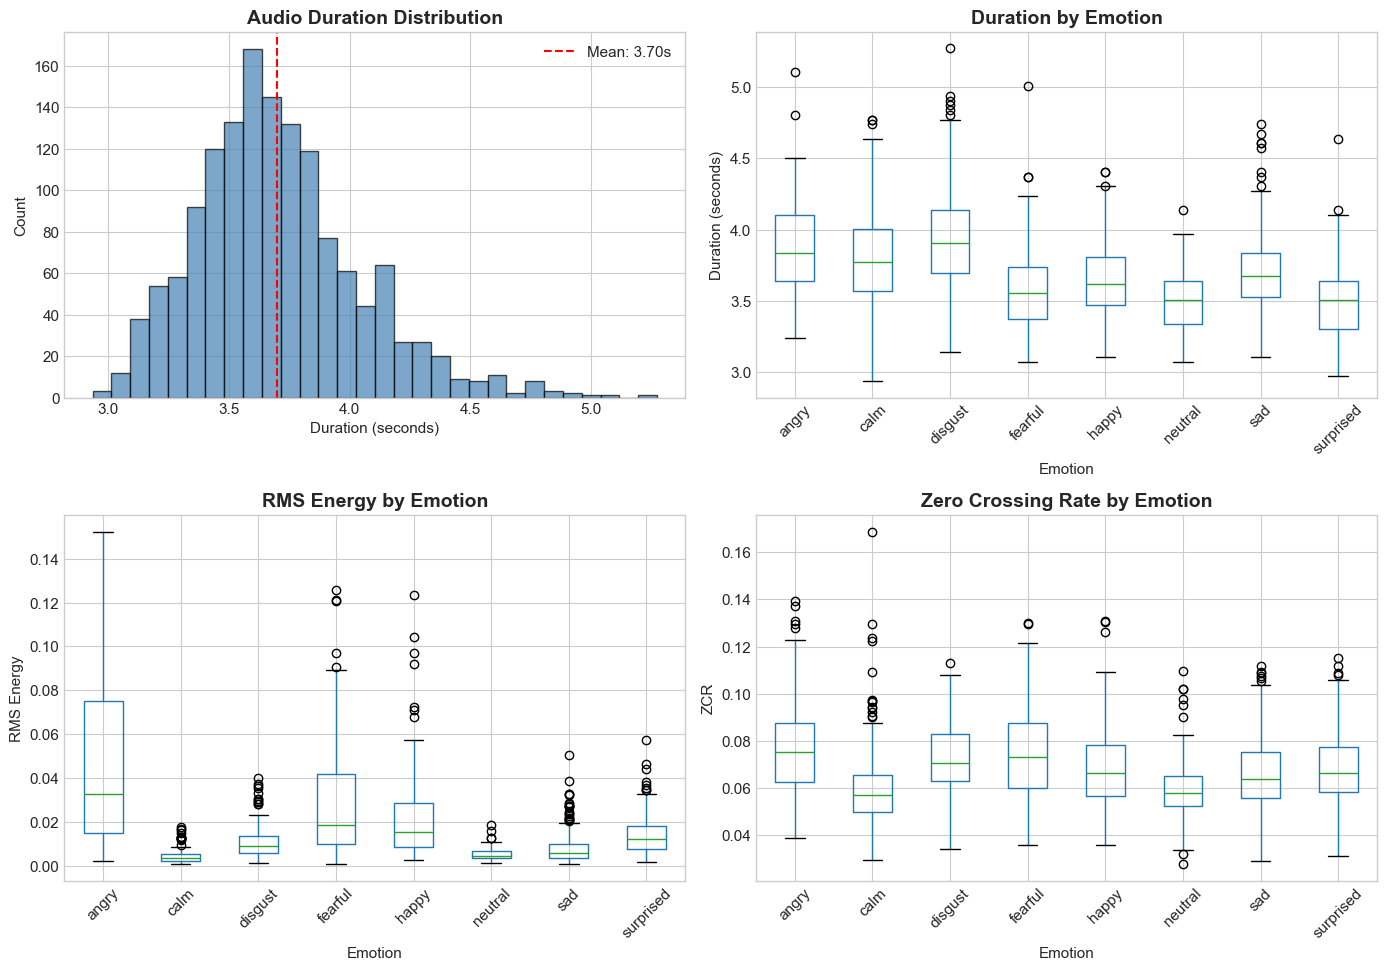

In [17]:
# Audio properties summary
print("\nAudio Properties Summary:")
print("=" * 50)
print(f"Sample rate: {df['sample_rate'].unique()} Hz")
print(f"Duration: {df['duration'].min():.2f}s - {df['duration'].max():.2f}s (mean: {df['duration'].mean():.2f}s)")
print(f"RMS Energy: {df['rms_energy'].min():.4f} - {df['rms_energy'].max():.4f}")

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Duration distribution
axes[0, 0].hist(df['duration'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['duration'].mean(), color='red', linestyle='--', label=f'Mean: {df["duration"].mean():.2f}s')
axes[0, 0].set_title('Audio Duration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# Duration by emotion
df.boxplot(column='duration', by='emotion_label', ax=axes[0, 1])
axes[0, 1].set_title('Duration by Emotion', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Emotion')
axes[0, 1].set_ylabel('Duration (seconds)')
plt.suptitle('')
axes[0, 1].tick_params(axis='x', rotation=45)

# RMS Energy by emotion
df.boxplot(column='rms_energy', by='emotion_label', ax=axes[1, 0])
axes[1, 0].set_title('RMS Energy by Emotion', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Emotion')
axes[1, 0].set_ylabel('RMS Energy')
plt.suptitle('')
axes[1, 0].tick_params(axis='x', rotation=45)

# Zero crossing rate by emotion
df.boxplot(column='zero_crossing_rate', by='emotion_label', ax=axes[1, 1])
axes[1, 1].set_title('Zero Crossing Rate by Emotion', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Emotion')
axes[1, 1].set_ylabel('ZCR')
plt.suptitle('')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_audio_properties.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Waveform & Spectrogram Visualization

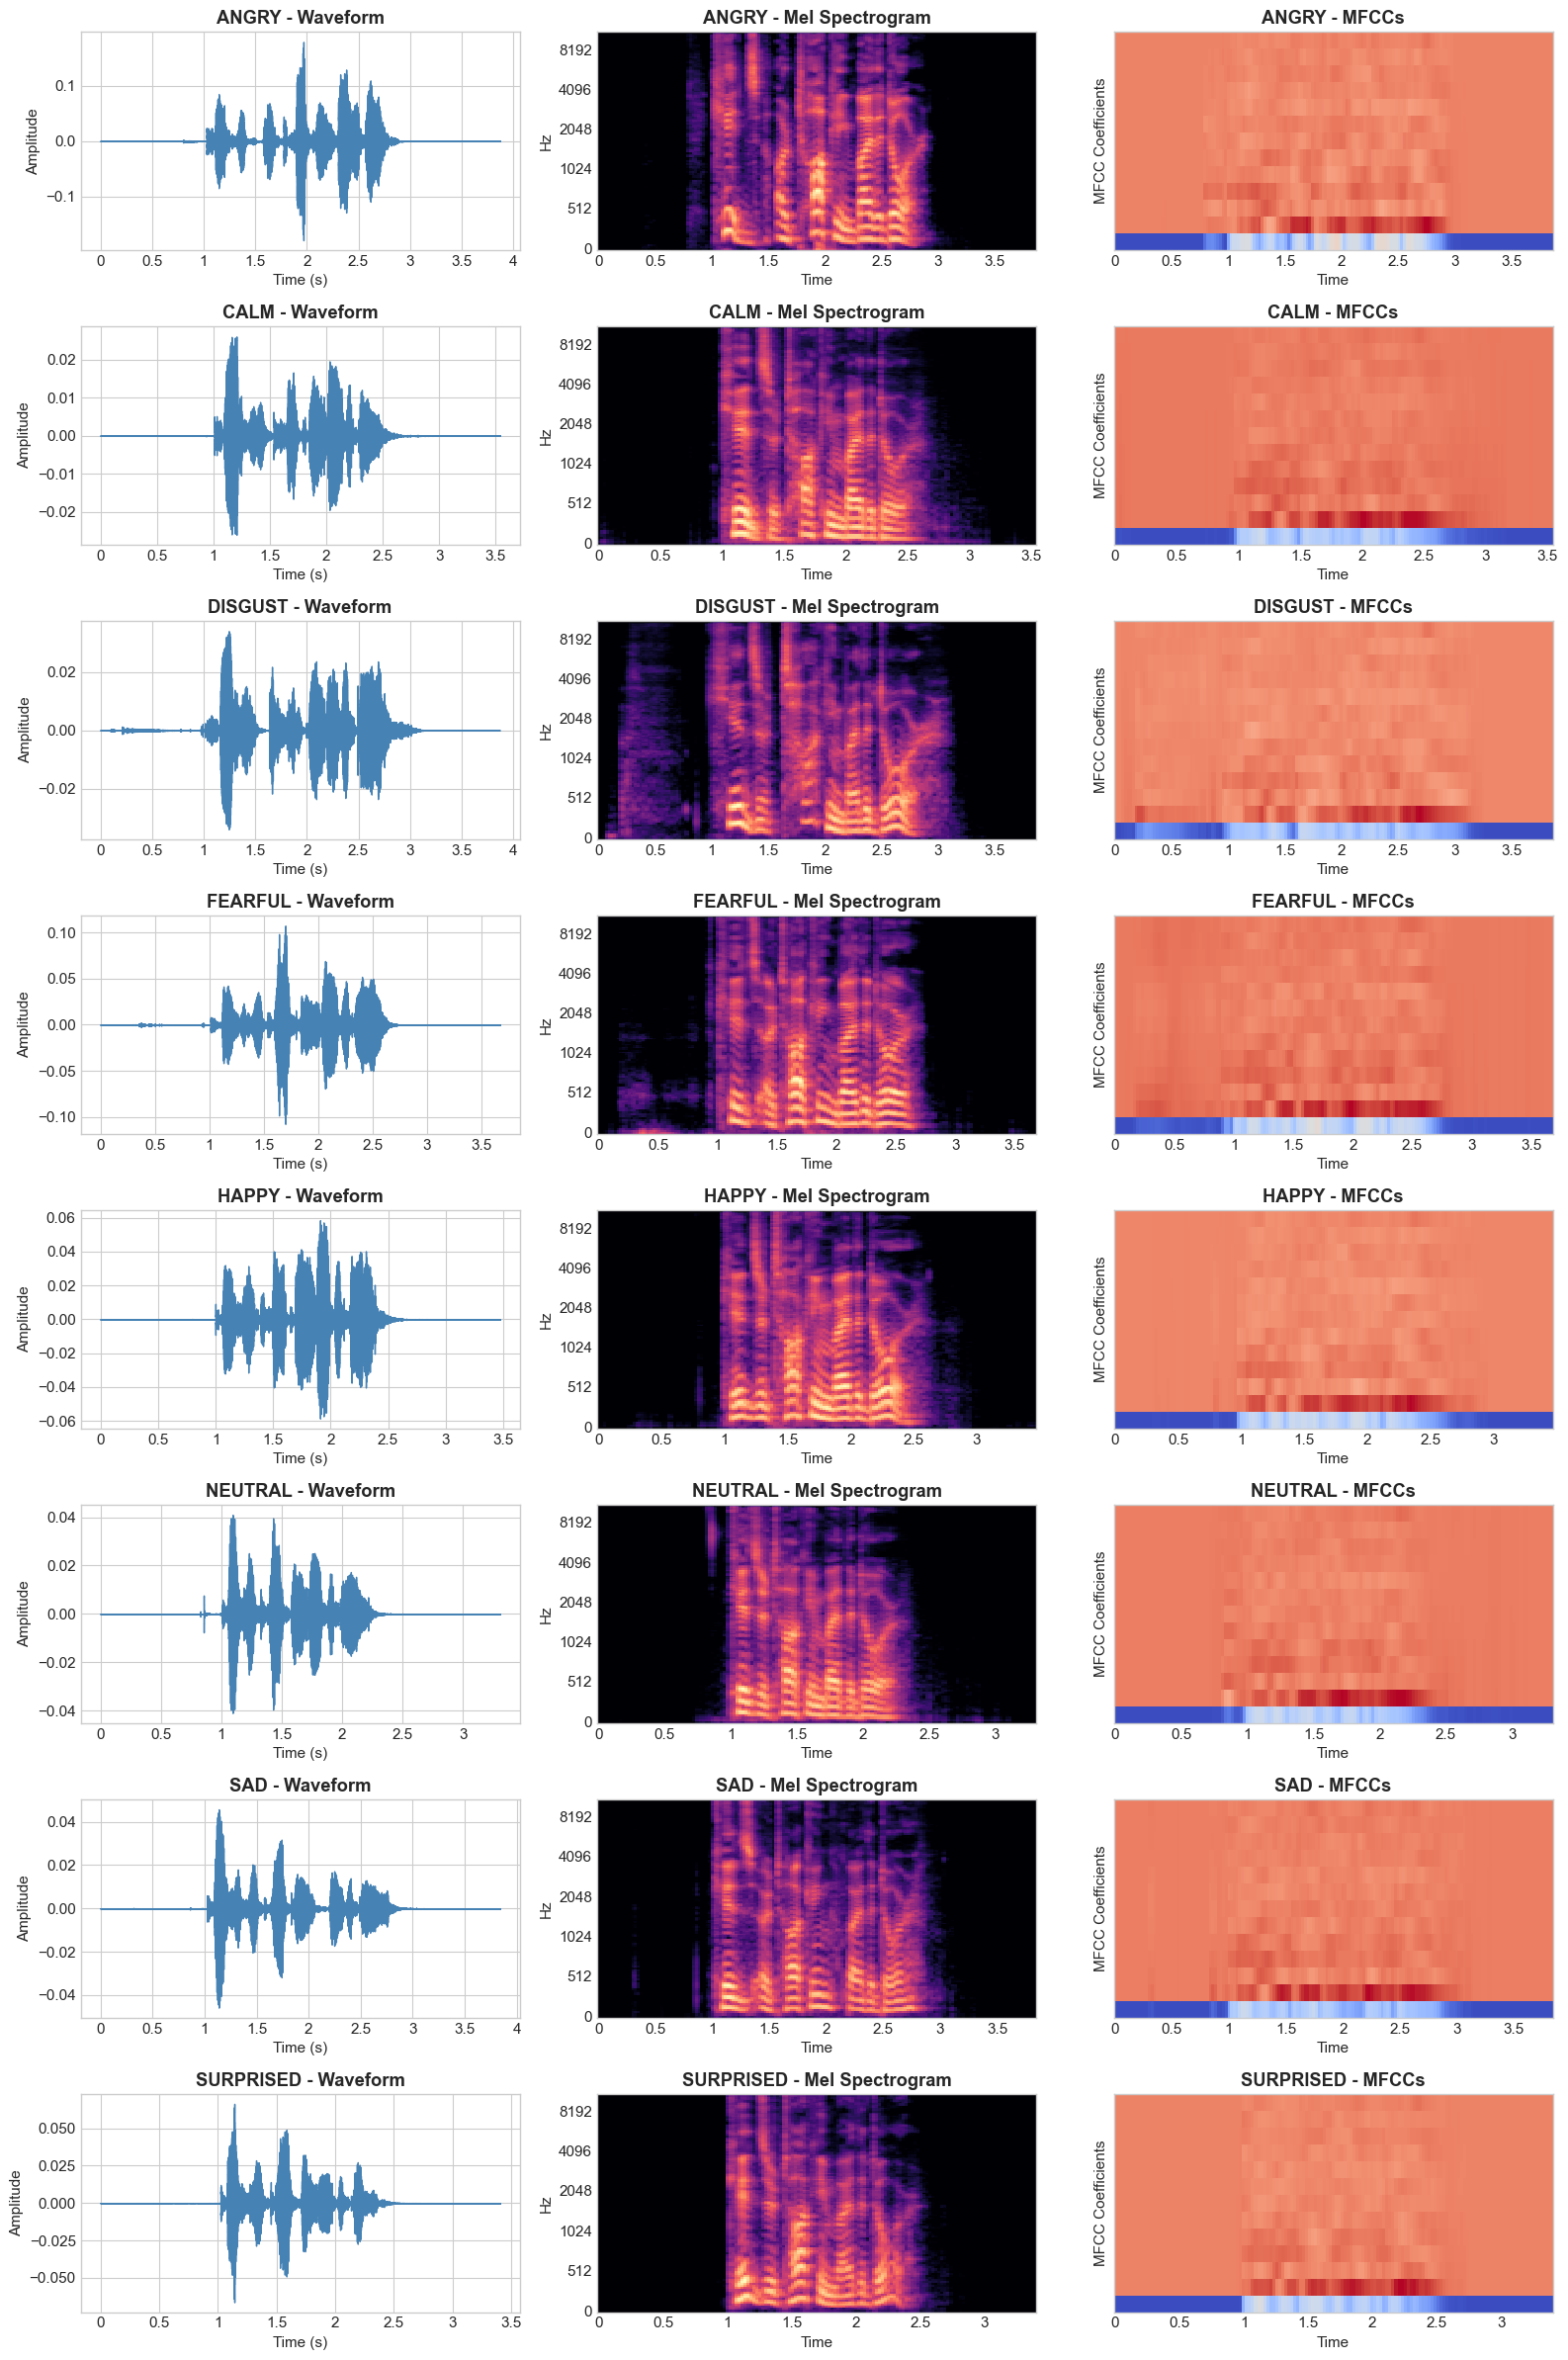

In [18]:
# Select one sample per emotion for visualization
emotions = sorted(df['emotion_label'].unique())
sample_files = df.groupby('emotion_label').first()['file_path']

fig, axes = plt.subplots(len(emotions), 3, figsize=(16, 3*len(emotions)))

for i, emotion in enumerate(emotions):
    filepath = sample_files[emotion]
    y, sr = librosa.load(filepath, sr=22050)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{emotion.upper()} - Waveform', fontweight='bold')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'{emotion.upper()} - Mel Spectrogram', fontweight='bold')
    
    # MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[i, 2], cmap='coolwarm')
    axes[i, 2].set_title(f'{emotion.upper()} - MFCCs', fontweight='bold')
    axes[i, 2].set_ylabel('MFCC Coefficients')

plt.tight_layout()
plt.savefig('eda_waveforms_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Extraction

In [19]:
def extract_features(file_path, sr=22050):
    """Extract comprehensive audio features for emotion recognition."""
    y, sr = librosa.load(file_path, sr=sr)
    
    features = {}
    
    # MFCCs (13 coefficients + delta + delta-delta = 39 features)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
    
    for i in range(13):
        features[f'mfcc_{i}_mean'] = np.mean(mfccs[i])
        features[f'mfcc_{i}_std'] = np.std(mfccs[i])
        features[f'mfcc_delta_{i}_mean'] = np.mean(mfcc_delta[i])
        features[f'mfcc_delta2_{i}_mean'] = np.mean(mfcc_delta2[i])
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = np.mean(chroma)
    features['chroma_std'] = np.std(chroma)
    
    # Spectral features
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = np.mean(spec_cent)
    features['spectral_centroid_std'] = np.std(spec_cent)
    
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['spectral_bandwidth_mean'] = np.mean(spec_bw)
    features['spectral_bandwidth_std'] = np.std(spec_bw)
    
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['spectral_rolloff_mean'] = np.mean(spec_rolloff)
    features['spectral_rolloff_std'] = np.std(spec_rolloff)
    
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    features['spectral_contrast_mean'] = np.mean(spec_contrast)
    features['spectral_contrast_std'] = np.std(spec_contrast)
    
    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    # RMS Energy
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    # Tempo - handle both old and new librosa versions
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    # In newer librosa versions, tempo is an array; in older versions, it's a scalar
    if hasattr(tempo, '__len__'):
        features['tempo'] = float(tempo[0]) if len(tempo) > 0 else 0.0
    else:
        features['tempo'] = float(tempo)
    
    # Pitch (F0)
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch_values = []
    for t in range(pitches.shape[1]):
        index = magnitudes[:, t].argmax()
        pitch = pitches[index, t]
        if pitch > 0:
            pitch_values.append(pitch)
    if pitch_values:
        features['pitch_mean'] = np.mean(pitch_values)
        features['pitch_std'] = np.std(pitch_values)
        features['pitch_max'] = np.max(pitch_values)
        features['pitch_min'] = np.min(pitch_values)
    else:
        features['pitch_mean'] = 0
        features['pitch_std'] = 0
        features['pitch_max'] = 0
        features['pitch_min'] = 0
    
    return features

print("Extracting features from all audio files...")
all_features = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    try:
        features = extract_features(row['file_path'])
        features['emotion_label'] = row['emotion_label']
        features['gender'] = row['gender']
        features['intensity'] = row['intensity_label']
        features['actor_id'] = row['actor_id']
        all_features.append(features)
    except Exception as e:
        print(f"Error: {e}")

features_df = pd.DataFrame(all_features)
print(f"\nFeature matrix shape: {features_df.shape}")
print(f"Number of features: {features_df.shape[1] - 4}")

Extracting features from all audio files...


Extracting features:   0%|          | 1/1440 [00:00<03:49,  6.28it/s]

Error: only 0-dimensional arrays can be converted to Python scalars


Extracting features:   0%|          | 3/1440 [00:00<02:25,  9.89it/s]

Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars

...

Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars


Extracting features:  28%|██▊       | 408/1440 [00:24<00:57, 18.06it/s]

Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars
Error: only 0-dimensional arrays can be converted to Python scalars


Extracting features:  28%|██▊       | 408/1440 [00:24<01:01, 16.67it/s]


KeyboardInterrupt: 

In [ ]:
# Save features for later use
features_df.to_csv('extracted_features.csv', index=False)
print("Features saved to extracted_features.csv")
features_df.head()

Features saved to extracted_features.csv


""


## 7. Feature Distributions by Emotion

KeyError: 'emotion_label'

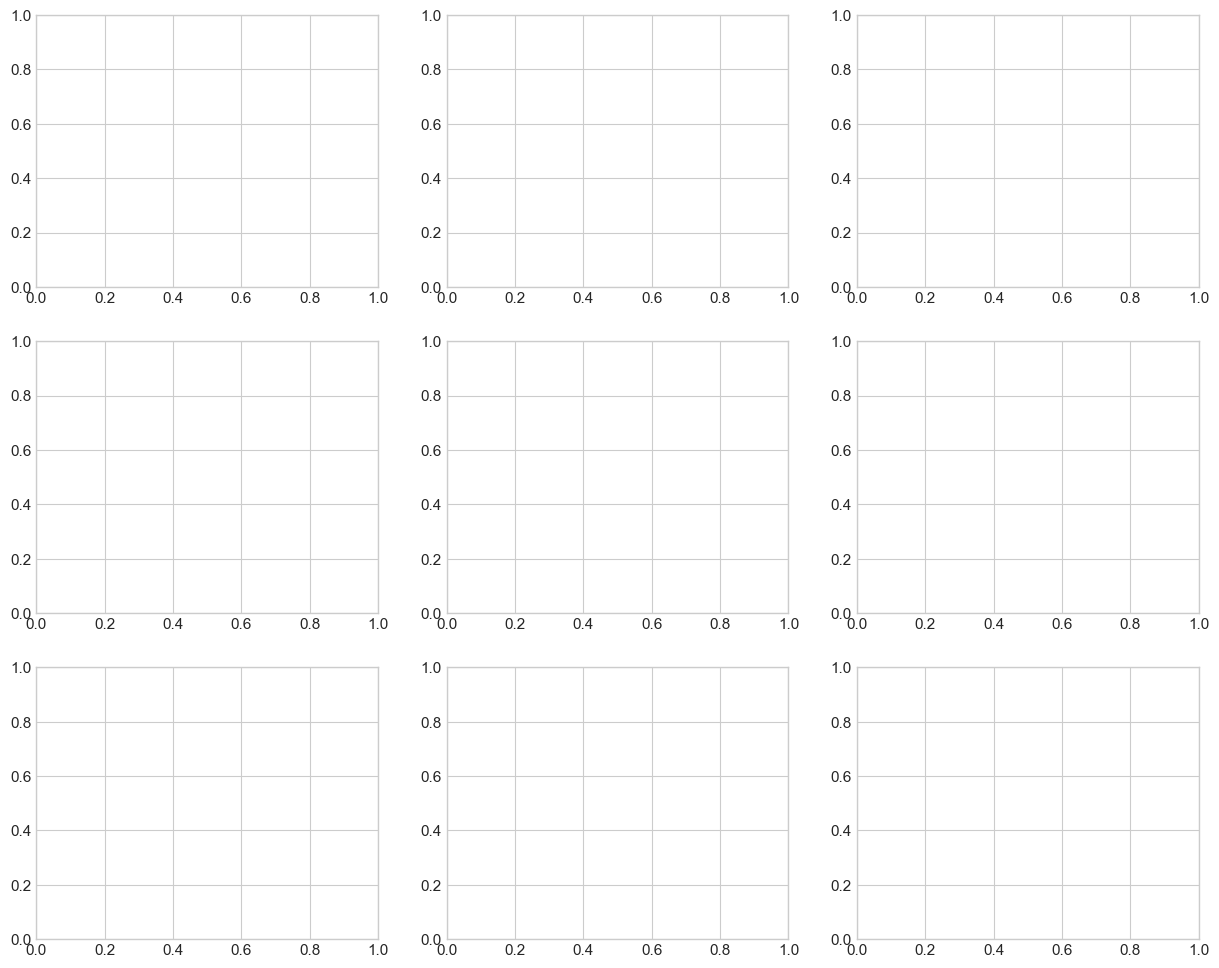

In [ ]:
# Key features to visualize
key_features = ['mfcc_0_mean', 'mfcc_1_mean', 'spectral_centroid_mean', 
                'rms_mean', 'zcr_mean', 'pitch_mean', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if i >= len(axes):
        break
    for emotion in emotions:
        data = features_df[features_df['emotion_label'] == emotion][feature]
        axes[i].hist(data, bins=20, alpha=0.5, label=emotion, density=True)
    axes[i].set_title(f'{feature} Distribution', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Violin plots for better distribution comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_features = ['mfcc_0_mean', 'spectral_centroid_mean', 'rms_mean', 
                 'zcr_mean', 'pitch_mean', 'tempo']

for i, feature in enumerate(plot_features):
    sns.violinplot(data=features_df, x='emotion_label', y=feature, ax=axes[i], palette='Set3')
    axes[i].set_title(f'{feature} by Emotion', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Dimensionality Reduction (PCA & t-SNE)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Prepare feature matrix
feature_cols = [c for c in features_df.columns if c not in ['emotion_label', 'gender', 'intensity', 'actor_id']]
X = features_df[feature_cols].values
y = features_df['emotion_label'].values

# Handle any NaN/inf
X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

In [ ]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
print("Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
for emotion in emotions:
    mask = y == emotion
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=emotion, alpha=0.6, s=50)
axes[0].set_title(f'PCA (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# t-SNE plot
for emotion in emotions:
    mask = y == emotion
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=emotion, alpha=0.6, s=50)
axes[1].set_title('t-SNE Visualization', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda_dimensionality_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations:")
print("- PCA shows some clustering but significant overlap between emotions")
print("- t-SNE reveals better separation, especially for extreme emotions (angry, happy)")
print("- Similar emotions (calm/neutral, sad/fearful) tend to cluster together")

## 9. Correlation Analysis

In [ ]:
# Correlation heatmap for key features
key_feature_cols = ['mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean',
                    'spectral_centroid_mean', 'spectral_bandwidth_mean', 
                    'spectral_rolloff_mean', 'spectral_contrast_mean',
                    'rms_mean', 'zcr_mean', 'pitch_mean', 'tempo', 'chroma_mean']

corr_matrix = features_df[key_feature_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated features
print("\nHighly correlated feature pairs (|r| > 0.7):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  {corr_matrix.index[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

## 10. Actor & Gender Analysis

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pitch by gender
sns.boxplot(data=features_df, x='emotion_label', y='pitch_mean', hue='gender', ax=axes[0, 0])
axes[0, 0].set_title('Pitch by Emotion and Gender', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# RMS by gender
sns.boxplot(data=features_df, x='emotion_label', y='rms_mean', hue='gender', ax=axes[0, 1])
axes[0, 1].set_title('RMS Energy by Emotion and Gender', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Spectral centroid by intensity
sns.boxplot(data=features_df, x='emotion_label', y='spectral_centroid_mean', hue='intensity', ax=axes[1, 0])
axes[1, 0].set_title('Spectral Centroid by Emotion and Intensity', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Actor variability
actor_mfcc = features_df.groupby('actor_id')['mfcc_0_mean'].mean().sort_index()
axes[1, 1].bar(range(len(actor_mfcc)), actor_mfcc.values, color='steelblue')
axes[1, 1].set_title('Average MFCC_0 by Actor', fontweight='bold')
axes[1, 1].set_xlabel('Actor ID')
axes[1, 1].set_ylabel('Mean MFCC_0')
axes[1, 1].set_xticks(range(len(actor_mfcc)))
axes[1, 1].set_xticklabels(actor_mfcc.index, rotation=45)

plt.tight_layout()
plt.savefig('eda_actor_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Intensity Analysis

In [ ]:
# Compare normal vs strong intensity
intensity_comparison = features_df.groupby(['emotion_label', 'intensity'])[['rms_mean', 'pitch_mean', 'spectral_centroid_mean']].mean().unstack()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMS comparison
intensity_comparison['rms_mean'].plot(kind='bar', ax=axes[0], color=['#90EE90', '#FFB347'])
axes[0].set_title('RMS Energy: Normal vs Strong', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Normal', 'Strong'])

# Pitch comparison
intensity_comparison['pitch_mean'].plot(kind='bar', ax=axes[1], color=['#90EE90', '#FFB347'])
axes[1].set_title('Pitch: Normal vs Strong', fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Normal', 'Strong'])

# Spectral centroid comparison
intensity_comparison['spectral_centroid_mean'].plot(kind='bar', ax=axes[2], color=['#90EE90', '#FFB347'])
axes[2].set_title('Spectral Centroid: Normal vs Strong', fontweight='bold')
axes[2].set_xlabel('Emotion')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(['Normal', 'Strong'])

plt.tight_layout()
plt.savefig('eda_intensity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Strong intensity generally shows higher RMS energy (louder)")
print("- Pitch tends to be higher for strong intensity emotions")
print("- Spectral centroid (brightness) increases with intensity")

## 12. Summary Statistics

In [ ]:
# Summary statistics by emotion
summary_features = ['mfcc_0_mean', 'rms_mean', 'pitch_mean', 'spectral_centroid_mean', 'zcr_mean', 'tempo']
summary_stats = features_df.groupby('emotion_label')[summary_features].agg(['mean', 'std'])

print("\n" + "=" * 80)
print("FEATURE SUMMARY STATISTICS BY EMOTION")
print("=" * 80)
print(summary_stats.round(3))

## 13. Key Findings & Recommendations

In [ ]:
print("""
===============================================================================
                          EDA KEY FINDINGS
===============================================================================

1. DATASET CHARACTERISTICS
   - 1,440 audio files from 24 actors (12 male, 12 female)
   - 8 emotions, but 'neutral' has half the samples (no 'strong' intensity)
   - Balanced gender distribution
   - Audio duration: 3-5 seconds, 48kHz sampling rate

2. DISTINGUISHING FEATURES BY EMOTION
   - Angry: High RMS energy, high pitch, high spectral centroid
   - Calm/Neutral: Low energy, steady pitch, lower spectral features
   - Happy: High pitch variability, moderate energy
   - Sad: Low energy, low pitch, slow tempo
   - Fearful: High pitch, variable energy, high ZCR
   - Surprised: High pitch peaks, sudden energy changes

3. FEATURE IMPORTANCE (for modeling)
   - MFCCs (especially 0-4): Capture spectral envelope, voice quality
   - Pitch statistics: Strong discriminator for arousal
   - RMS energy: Distinguishes high vs low arousal emotions
   - Spectral features: Help separate bright vs dark emotions

4. CHALLENGES
   - Overlap between similar emotions (calm/neutral, sad/fearful)
   - Actor-specific variations in expression
   - Gender differences in pitch (need normalization)
   - Class imbalance (neutral underrepresented)

5. RECOMMENDATIONS FOR MODELING
   - Use MFCC + delta + delta-delta features as baseline
   - Add spectral and prosodic features for improvement
   - Consider pitch normalization by gender
   - Address class imbalance (oversample neutral or use class weights)
   - Try CNN on mel-spectrograms for deep learning approach
   - Consider actor-independent train/test split for generalization

===============================================================================
""")

---

# Deep Learning Problem Formulations

Based on the EDA findings, here are several deep learning approaches for Speech Emotion Recognition, organized by architecture type and increasing complexity.

## Problem 1: LSTM/GRU for Sequence Classification

### Problem Statement
**Goal**: Classify emotion from a sequence of audio features (MFCCs over time frames).

### Why This Architecture?
- Speech is inherently **sequential** - emotions unfold over time
- LSTMs/GRUs can capture **long-term dependencies** (e.g., rising anger throughout an utterance)
- Handles **variable-length** audio clips naturally

### Input/Output
- **Input**: Sequence of MFCC frames `(batch, time_steps, n_mfcc)` e.g., `(32, 100, 40)`
- **Output**: 8-class probability distribution `(batch, 8)`

### Architecture
```
Input (time_steps, 40 MFCCs)
    |
    v
Bidirectional LSTM (128 units) -- captures past AND future context
    |
    v
Bidirectional LSTM (64 units)
    |
    v
Global Average Pooling -- aggregate across time
    |
    v
Dense (64, ReLU) + Dropout(0.3)
    |
    v
Dense (8, Softmax) -- emotion probabilities
```

### Key Considerations
- Use **bidirectional** LSTMs since we have the full utterance (not real-time)
- **Attention mechanism** can highlight emotionally salient frames
- Consider **GRUs** for faster training with similar performance

## Problem 4: Variational Autoencoder (VAE) for Emotion Space

### Problem Statement
**Goal**: Learn a smooth, continuous latent space where similar emotions cluster together, enabling:
- Better generalization
- Emotion interpolation (morph between emotions)
- Data augmentation by sampling

### Why VAE over Regular Autoencoder?
- VAE learns a **probabilistic** latent space (Gaussian distribution)
- **Regularized** latent space prevents overfitting, encourages smoothness
- Can **generate** new samples by sampling from latent space

### Architecture
```
ENCODER:
Input Spectrogram
    |
    v
Conv2D layers --> Flatten
    |
    v
+-------+-------+
|               |
v               v
mu (mean)    log_var (variance)  -- parameters of latent distribution
    \           /
     \         /
      v       v
    z = mu + exp(0.5*log_var) * epsilon  -- reparameterization trick
             |
             v
DECODER:
Dense --> Reshape --> ConvTranspose2D layers
             |
             v
    Reconstructed Spectrogram
```

### Loss Function
```
VAE_Loss = Reconstruction_Loss (MSE) + KL_Divergence (regularization)
```

### Applications
- **Emotion interpolation**: Sample between angry and calm in latent space
- **Data augmentation**: Generate new training samples
- **Anomaly detection**: Identify unusual emotional expressions

## Problem 6: Transformer for Speech Emotion Recognition

### Problem Statement
**Goal**: Use self-attention to model relationships between ALL time frames simultaneously, capturing global emotional patterns.

### Why Transformers?
- **Parallelizable** - faster training than sequential LSTMs
- **Global context** - every frame attends to every other frame
- **State-of-the-art** in speech processing (Wav2Vec, HuBERT, Whisper)
- No vanishing gradient problem across long sequences

### Architecture Options

#### Option A: Transformer Encoder Only (Classification)
```
Input: MFCC Sequence (T, 40) + Positional Encoding
    |
    v
Transformer Encoder Block x N:
    - Multi-Head Self-Attention (8 heads)
    - Feed-Forward Network
    - Layer Normalization + Residual Connections
    |
    v
[CLS] token output OR Global Average Pooling
    |
    v
Dense(8, Softmax) --> Emotion
```

```

### Key Components Explained
- **Positional Encoding**: Since attention has no inherent order, we add position info
- **Multi-Head Attention**: Multiple attention "perspectives" (pitch, energy, rhythm)
- **[CLS] Token**: Special token whose output represents the whole sequence

## Problem 7: Multi-Task Learning (Emotion + Auxiliary Tasks)

### Problem Statement
**Goal**: Improve emotion recognition by jointly predicting related tasks (gender, intensity, speaker ID).

### Why Multi-Task?
- **Shared representations** learn more robust features
- **Regularization** - auxiliary tasks prevent overfitting to emotion labels
- **Leverages EDA finding**: Gender and intensity strongly correlate with features

### Architecture
```
Input: Mel-Spectrogram
    |
    v
SHARED ENCODER (CNN or Transformer)
    |
    v
Shared Representation (256-dim)
    |
+---+---+---+---+
|   |   |   |   |
v   v   v   v   v
Head1  Head2  Head3  Head4
Emotion Gender Intensity Speaker
(8-cls) (2-cls) (2-cls)  (24-cls)
```

### Loss Function
```python
total_loss = (lambda_1 * emotion_loss + 
              lambda_2 * gender_loss + 
              lambda_3 * intensity_loss + 
              lambda_4 * speaker_loss)
```

### Benefits for This Dataset
- Gender prediction helps learn pitch normalization
- Intensity prediction helps distinguish arousal levels
- Speaker prediction encourages speaker-invariant emotion features

## Summary: Choosing the Right Architecture

| Architecture | Best For | Complexity | Data Needs | Key Advantage |
|-------------|----------|------------|------------|---------------|
| **LSTM/GRU** | Baseline, sequence modeling | Low | Medium | Simple, effective for temporal patterns |
| **CNN-LSTM** | Spectral + temporal | Medium | Medium | Best of both worlds |
| **Autoencoder** | Unsupervised pre-training | Medium | Low (unlabeled OK) | Learn without labels first |
| **VAE** | Data augmentation, interpolation | Medium-High | Medium | Generate new samples |
| **Attention Seq2Seq** | Interpretability | Medium | Medium | See where model looks |
| **Transformer** | State-of-the-art performance | High | High | Best accuracy, parallelizable |
| **Multi-Task** | Robust features | Medium-High | Medium | Leverages auxiliary labels |

### Recommended Starting Point for RAVDESS
1. **Baseline**: CNN on mel-spectrograms (simple, fast)
2. **Intermediate**: CNN-LSTM hybrid or LSTM with attention
3. **Advanced**: Fine-tune pre-trained Wav2Vec 2.0 or HuBERT

### Evaluation Strategy
- Use **Leave-One-Speaker-Out** cross-validation for generalization testing
- Report **per-class F1** due to neutral class imbalance
- Confusion matrix to identify commonly confused emotion pairs